In [19]:
import pandas as pd

df = pd.read_csv("../data/raw/papers.csv")

df.head()


,title,year,authors,citations,doi,paper_url,abstract
0,Retrieval-Augmented Generation for Large Langu...,2023,"Yunfan Gao, Yun Xiong, Xinyu Gao, Kangxiang Ji...",704,https://doi.org/10.48550/arxiv.2312.10997,http://arxiv.org/abs/2312.10997,"{'Large': [0], 'Language': [1], 'Models': [2],..."
1,Active Retrieval Augmented Generation,2023,"Zhengbao Jiang, Frank F. Xu, Luyu Gao, Zhiqing...",417,https://doi.org/10.18653/v1/2023.emnlp-main.495,https://doi.org/10.18653/v1/2023.emnlp-main.495,"{'Zhengbao': [0], 'Jiang,': [1], 'Frank': [2],..."
2,Benchmarking Large Language Models in Retrieva...,2024,"Jiawei Chen, Hongyu Lin, Xianpei Han, Le Sun",366,https://doi.org/10.1609/aaai.v38i16.29728,https://doi.org/10.1609/aaai.v38i16.29728,"{'Retrieval-Augmented': [0, 59, 96], 'Generati..."
3,RAGAs: Automated Evaluation of Retrieval Augme...,2024,"Shahul Es, Jithin James, Luis Espinosa-Anke, S...",391,https://doi.org/10.18653/v1/2024.eacl-demo.16,https://doi.org/10.18653/v1/2024.eacl-demo.16,"{'Shahul': [0], 'Es,': [1], 'Jithin': [2], 'Ja..."
4,Benchmarking Retrieval-Augmented Generation fo...,2024,"Guangzhi Xiong, Qiao Jin, Zhiyong Lu, Aidong Z...",248,https://doi.org/10.18653/v1/2024.findings-acl.372,https://doi.org/10.18653/v1/2024.findings-acl.372,"{'While': [0], 'large': [1], 'language': [2], ..."


In [20]:
df.shape


(500, 7)

In [21]:
df.columns


Index(['title', 'year', 'authors', 'citations', 'doi', 'paper_url',
       'abstract'],
      dtype='object')

In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      500 non-null    object
 1   year       500 non-null    int64 
 2   authors    500 non-null    object
 3   citations  500 non-null    int64 
 4   doi        499 non-null    object
 5   paper_url  500 non-null    object
 6   abstract   437 non-null    object
dtypes: int64(2), object(5)
memory usage: 27.5+ KB


In [23]:
df.isnull().sum()


title         0
year          0
authors       0
citations     0
doi           1
paper_url     0
abstract     63
dtype: int64

In [24]:
df.describe()


,year,citations
count,500.000000,500.000000
mean,2024.334000,42.148000
std,0.836567,159.963943
min,2020.000000,4.000000
25%,2024.000000,9.000000
50%,2024.000000,15.000000
75%,2025.000000,30.000000
max,2026.000000,3052.000000


In [25]:
df["year"].value_counts().sort_index()


year
2020      4
2021      3
2022      7
2023     30
2024    230
2025    216
2026     10
Name: count, dtype: int64

In [26]:
def reconstruct_abstract(inverted_index):
    if not inverted_index:
        return None

    words = []

    for word, positions in inverted_index.items():
        for position in positions:
            words.append((position, word))

    words.sort()

    return " ".join(word for position, word in words)


In [27]:
sample = df.loc[0, "abstract"]

print(sample)


{'Large': [0], 'Language': [1], 'Models': [2], '(LLMs)': [3], 'showcase': [4], 'impressive': [5], 'capabilities': [6], 'but': [7], 'encounter': [8], 'challenges': [9, 155], 'like': [10], 'hallucination,': [11], 'outdated': [12], 'knowledge,': [13], 'and': [14, 38, 47, 53, 93, 112, 146, 158, 165], 'non-transparent,': [15], 'untraceable': [16], 'reasoning': [17], 'processes.': [18], 'Retrieval-Augmented': [19], 'Generation': [20], '(RAG)': [21], 'has': [22], 'emerged': [23], 'as': [24], 'a': [25, 77, 130], 'promising': [26], 'solution': [27], 'by': [28], 'incorporating': [29], 'knowledge': [30, 51, 63], 'from': [31], 'external': [32, 70], 'databases.': [33, 71], 'This': [34, 72], 'enhances': [35], 'the': [36, 41, 65, 81, 87, 90, 94, 100, 108, 110, 113, 119, 134, 149, 154], 'accuracy': [37], 'credibility': [39], 'of': [40, 55, 69, 80, 83, 103, 125, 133], 'generation,': [42], 'particularly': [43], 'for': [44, 49, 163], 'knowledge-intensive': [45], 'tasks,': [46], 'allows': [48], 'continuou

In [28]:
import ast


In [29]:
def reconstruct_abstract(inverted_index):
    if pd.isna(inverted_index):
        return None

    inverted_index = ast.literal_eval(inverted_index)

    words = []

    for word, positions in inverted_index.items():
        for position in positions:
            words.append((position, word))

    words.sort()

    return " ".join(word for position, word in words)


In [30]:
df["abstract_text"] = df["abstract"].apply(reconstruct_abstract)


In [31]:
df[["title", "abstract_text"]].head()


,title,abstract_text
0,Retrieval-Augmented Generation for Large Langu...,Large Language Models (LLMs) showcase impressi...
1,Active Retrieval Augmented Generation,"Zhengbao Jiang, Frank Xu, Luyu Gao, Zhiqing Su..."
2,Benchmarking Large Language Models in Retrieva...,Retrieval-Augmented Generation (RAG) is a prom...
3,RAGAs: Automated Evaluation of Retrieval Augme...,"Shahul Es, Jithin James, Luis Espinosa Anke, S..."
4,Benchmarking Retrieval-Augmented Generation fo...,While large language models (LLMs) have achiev...


In [32]:
df["abstract_text"].isna().sum()


np.int64(63)

In [33]:
df["abstract_text"].iloc[0]


"Large Language Models (LLMs) showcase impressive capabilities but encounter challenges like hallucination, outdated knowledge, and non-transparent, untraceable reasoning processes. Retrieval-Augmented Generation (RAG) has emerged as a promising solution by incorporating knowledge from external databases. This enhances the accuracy and credibility of the generation, particularly for knowledge-intensive tasks, and allows for continuous knowledge updates and integration of domain-specific information. RAG synergistically merges LLMs' intrinsic knowledge with the vast, dynamic repositories of external databases. This comprehensive review paper offers a detailed examination of the progression of RAG paradigms, encompassing the Naive RAG, the Advanced RAG, and the Modular RAG. It meticulously scrutinizes the tripartite foundation of RAG frameworks, which includes the retrieval, the generation and the augmentation techniques. The paper highlights the state-of-the-art technologies embedded in

## 1. Papers published by year

How has research activity changed over time?

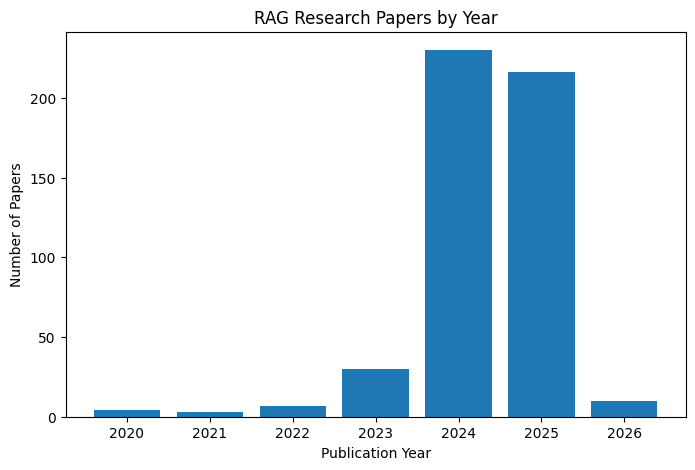

In [34]:
import matplotlib.pyplot as plt

year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Publication Year")
plt.ylabel("Number of Papers")
plt.title("RAG Research Papers by Year")
plt.show()


based on graph we can see that after 2022 there is increase in the number of papers 

## 2. Citation distribution

A citation in a research paper basically means another paper has referred to or used that paper in its own research.

Citation count = Number of other research papers that cite/reference this paper.

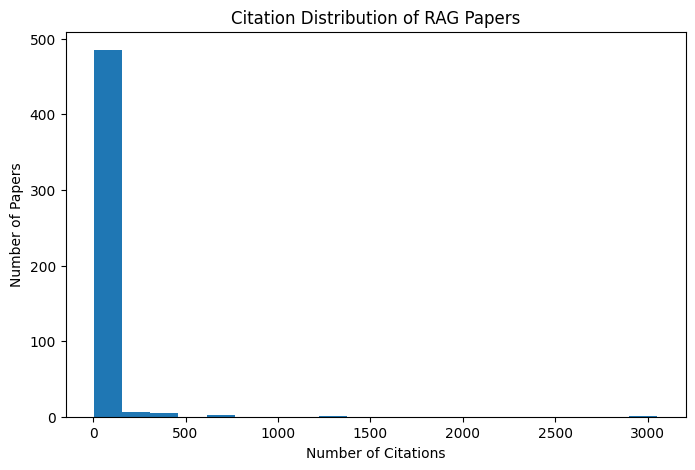

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(df["citations"], bins=20)
plt.xlabel("Number of Citations")
plt.ylabel("Number of Papers")
plt.title("Citation Distribution of RAG Papers")
plt.show()


Citation counts are highly skewed, with a small number of papers receiving very high citations.

## 3. Top 10 most-cited papers

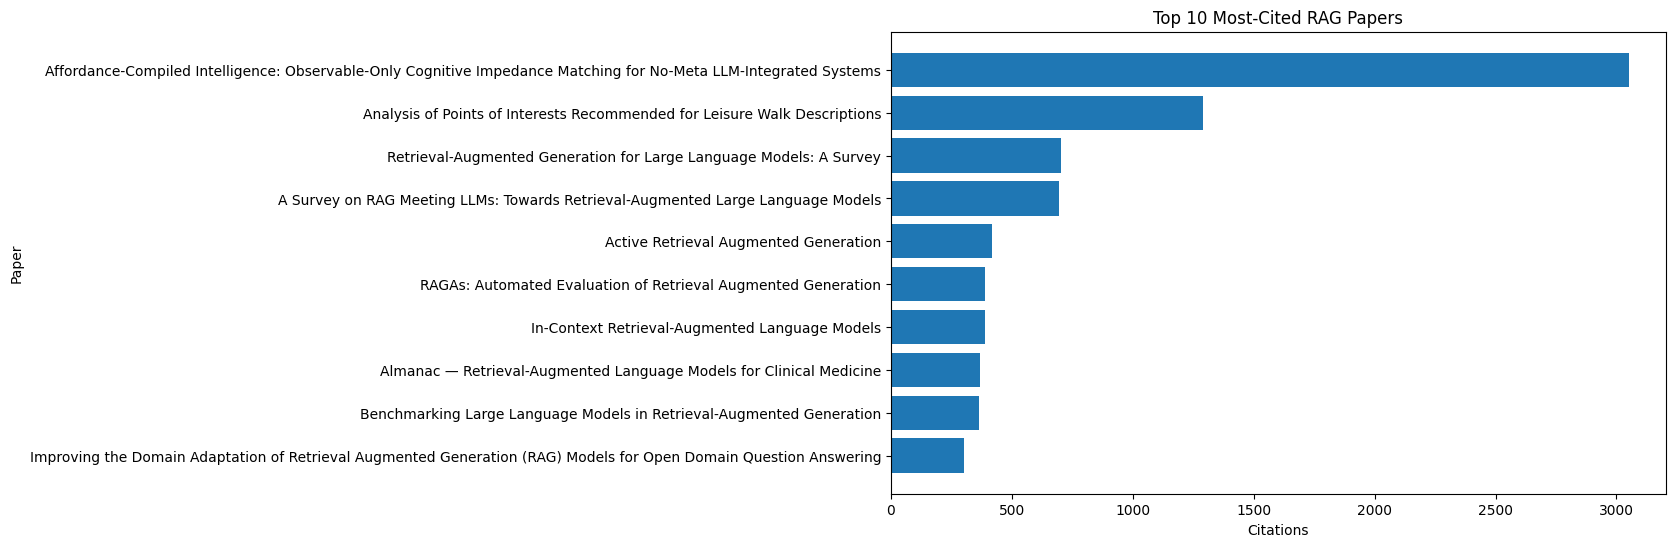

In [36]:
top_papers = df.nlargest(10, "citations")

plt.figure(figsize=(10, 6))
plt.barh(top_papers["title"], top_papers["citations"])
plt.xlabel("Citations")
plt.ylabel("Paper")
plt.title("Top 10 Most-Cited RAG Papers")
plt.gca().invert_yaxis()
plt.show()


Upon citation count few papers dominate 